In [27]:
from scipy.optimize import fsolve
import numpy as np
import math
from mpi4py import MPI
from petsc4py import PETSc

from dolfinx import mesh, fem, io 
import dolfinx.fem.petsc
import ufl
from basix.ufl import element
import ufl.constant


def solve_darcy(k_sample, f, mesh, V):
    u_D = fem.Function(V)
    # u_D.interpolate(
    #     lambda x: -1 / (4 * (np.pi**2)) * np.sin(2 * np.pi * x[0])
    #     - 1 / (4 * (np.pi**2)) * np.cos(2 * np.pi * x[1])
    # )
    u_left = fem.Function(V)
    u_left.interpolate(lambda x: np.full(x.shape[1], .4))
    u_right = fem.Function(V)
    u_right.interpolate(lambda x: np.full(x.shape[1], 0.0))
    u_bottom = fem.Function(V)
    u_bottom.interpolate(lambda x: np.full(x.shape[1], .1))
    u_top = fem.Function(V)
    u_top.interpolate(lambda x: np.full(x.shape[1], .0))


    left_boundary = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], 0))
    right_boundary = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], 1))
    bottom_boundary = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[1], 0))
    top_boundary = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[1], 1))
    bcs = [
        fem.dirichletbc(u_left, left_boundary),
        fem.dirichletbc(u_right, right_boundary),
        fem.dirichletbc(u_bottom, bottom_boundary),
        fem.dirichletbc(u_top, top_boundary),
    ]
    dx_mesh = ufl.dx(domain=mesh)
    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)
    a = -ufl.dot(k_sample * ufl.grad(u), ufl.grad(v)) * dx_mesh
    L = f * v * dx_mesh
    u_sol = fem.Function(V)
    problem = fem.petsc.LinearProblem(
        a, L, bcs=bcs, petsc_options={"ksp_type": "cg", "pc_type": "hypre"}
    )
    u_sol = problem.solve()
    return u_sol


def solve_transcendental_equation(lambda_value, num_modes):
    def equation(w):
        return np.tan(w) - (2 * lambda_value * w) / (lambda_value**2 * w**2 - 1)

    w_n = [1.72066]
    for n in range(1, num_modes):
        initial_guess = n * np.pi
        w_n.append(fsolve(equation, initial_guess)[0])
    return w_n


lam = 0.5
dom = np.linspace(0, 1, 1000)

wn = solve_transcendental_equation(0.5, 100)
wn = np.array(wn)
thetan_1D = 2 * lam / (lam**2 * wn**2 + 1)
bn = np.zeros((len(dom), len(wn)))
An = np.zeros(len(wn))
for j in range(len(wn)):
    for i in range(len(dom)):
        bn[i, j] = np.sin(wn[j] * dom[i]) + lam * wn[j] * np.cos(wn[j] * dom[i])
    An[j] = 1 / np.sqrt(np.trapz(bn[:, j] ** 2, dom))


def generate_permeability_sample(norm_sample, wn, N_modes, mesh, V, sigma=1.0, lam=0.5):
    wn = np.array(wn)
    points = mesh.geometry.x
    num_points = points.shape[0]
    thetan_2D = np.zeros(N_modes)
    i = 0
    rowcolsum = 0
    rownum = 0
    colnum = rowcolsum
    k_array = np.zeros(num_points)
    while i < N_modes:
        if rownum > rowcolsum:
            rowcolsum += 1
            rownum = 0
            colnum = rowcolsum
        thetan_2D[i] = thetan_1D[rownum] * thetan_1D[colnum]
        scale_factor = norm_sample[i] * np.sqrt(thetan_2D[i])
        b1 = An[rownum] * (
            np.sin(wn[rownum] * points[:, 0])
            + lam * wn[rownum] * np.cos(wn[rownum] * points[:, 0])
        )
        b2 = An[colnum] * (
            np.sin(wn[colnum] * points[:, 1])
            + lam * wn[colnum] * np.cos(wn[colnum] * points[:, 1])
        )
        k_array += scale_factor * b1 * b2
        rownum += 1
        colnum -= 1
        i += 1
    k_array = np.exp(k_array)
    k_sample = fem.Function(V)
    k_sample.x.array[:] = k_array
    return k_sample

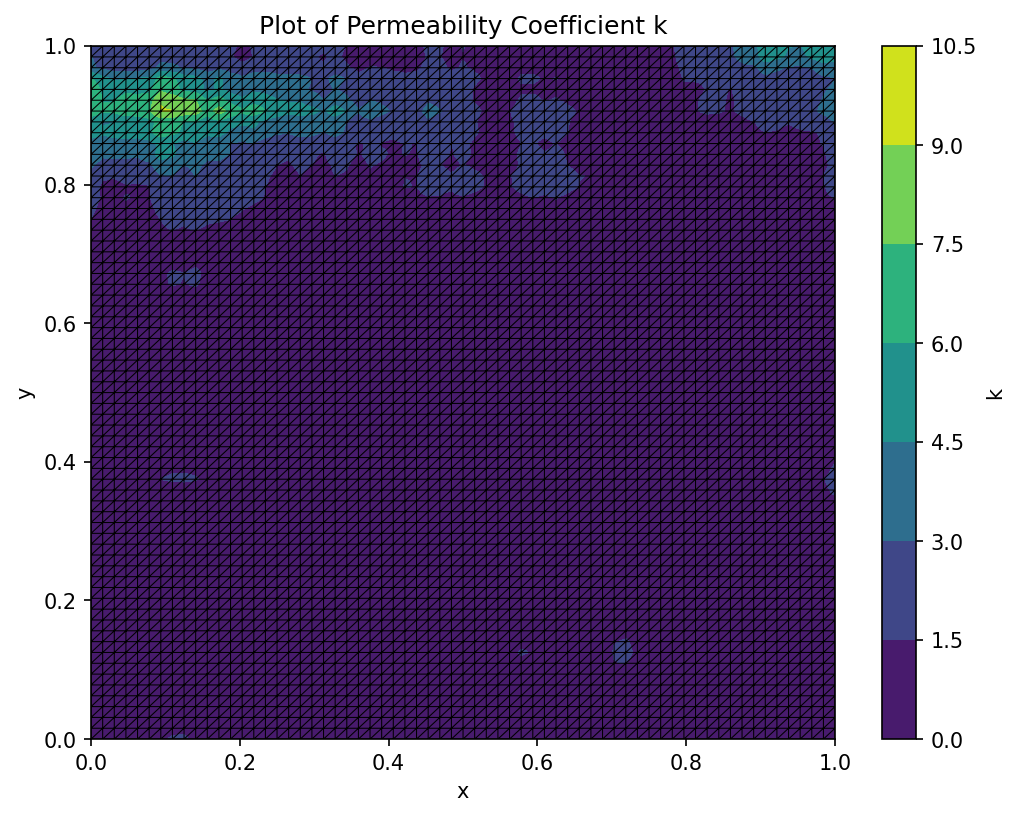

In [38]:
from dolfinx.mesh import create_unit_square, CellType
import pyvista as pv
lambda_value = 0.5
sigma = 10**(-5)
N_modes = 2000
# np.random.seed(45)


mesh = create_unit_square(MPI.COMM_WORLD, 64, 64, cell_type=CellType.triangle)
f = fem.Constant(mesh, dolfinx.default_scalar_type(-1))

V = fem.functionspace(mesh, ("Lagrange", 1))  
sol = np.random.normal(0, 1, N_modes)
lambda_value = 0.5
w_n = solve_transcendental_equation(lambda_value, N_modes)
k = generate_permeability_sample(sol, w_n, N_modes, mesh,V)

p_cor = solve_darcy(k, f,mesh,V)

import matplotlib.pyplot as plt
import matplotlib.tri as tri

# Extract the coordinates and connectivity from the mesh
x_coords = mesh.geometry.x
cells = mesh.topology.connectivity(mesh.topology.dim, 0).array.reshape(-1, 3)

# Retrieve the permeability values from k
k_values = k.x.array

# Create a triangulation (assuming triangular cells)
triangulation = tri.Triangulation(x_coords[:, 0], x_coords[:, 1], triangles=cells)

plt.figure(figsize=(8, 6), dpi=150)
plt.tricontourf(triangulation, k_values, cmap="viridis")
plt.triplot(triangulation, color="black", linewidth=0.5)
plt.colorbar(label="k")
plt.title("Plot of Permeability Coefficient k")
plt.xlabel("x")
plt.ylabel("y")
plt.show()




# # Prepare the VTK connectivity array. For each quadrilateral cell, prepend the number 4.
# num_quads = cells.shape[0]
# cells_vtk = np.hstack([np.full((num_quads, 1), 4, dtype=np.int64), cells]).flatten()

# # The VTK cell type for quadrilaterals is 9.
# cell_types = np.full(num_quads, 9, dtype=np.uint8)

# # Create the PyVista UnstructuredGrid.
# grid = pv.UnstructuredGrid(cells_vtk, cell_types, x_coords)

# # Plot the mesh with cell scalars from k_values.
# grid.plot(scalars=k_values, cmap="viridis", show_edges=False)

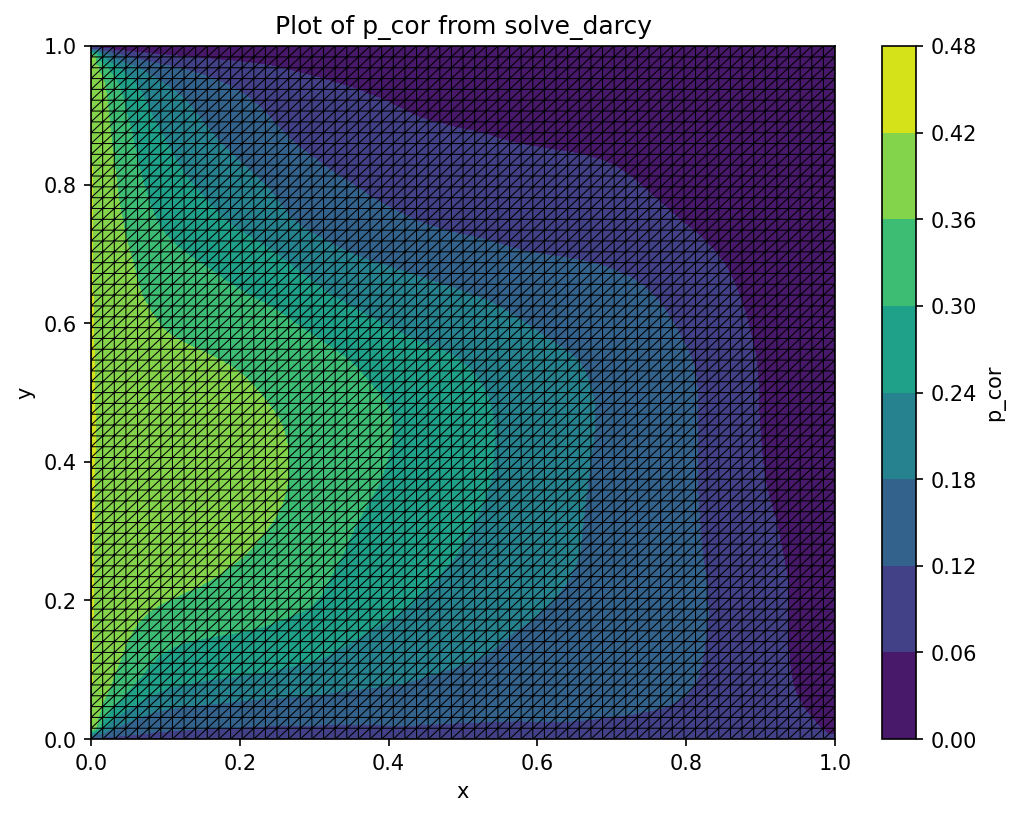

In [39]:
# Instead of using create_vtk_mesh (which is not available), we manually extract the mesh data:
x = mesh.geometry.x
cells = {"triangle": mesh.topology.connectivity(mesh.topology.dim, 0).array}

import matplotlib.pyplot as plt
import matplotlib.tri as tri

# Create a triangulation for plotting (assumes the mesh uses triangles)
triangulation = tri.Triangulation(x[:,0], x[:,1], triangles=mesh.topology.connectivity(mesh.topology.dim, 0).array.reshape((-1, 3)))

# Get the degrees of freedom for the p_cor solution (assumed to be nodal values)
values = p_cor.x.array

plt.figure(figsize=(8, 6), dpi=150)
plt.tricontourf(triangulation, values, cmap="viridis")
plt.triplot(triangulation, color="black", linewidth=0.5)

plt.colorbar(label="p_cor")
plt.title("Plot of p_cor from solve_darcy")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [ ]:
"""
This program solves steady-state Darcy's flow on a
square plate with spatially varying permeability.
        (K/mu)*u + grad(p) = 0
                  div(u) = 0
Which, in weak form reads:
 (v, (K/mu)*u) - (div(v), p) = 0           for all v
               (q, div(u)) = 0             for all q
"""


from dolfin import *
from fenics import *
#from mshr import *
from mshr import *
import numpy as np
import sys
import math
import numpy as np
from ufl import nabla_div


output_dir = './'




set_log_level(30)

domain = Rectangle(Point(0, 0), Point(1.0, 1.0))    
mesh = generate_mesh(domain, 150) #generate_mesh(domain, 100)
V = FunctionSpace(mesh, 'P', 1)  #1st order FEM


xdmffile_k = XDMFFile('results/porous_Ks.xdmf')
xdmffile_k.parameters['rewrite_function_mesh'] = False
xdmffile_k.parameters['flush_output'] = True


pi = math.pi


N_param = 15 


A_vals= np.linspace(0.,1.,N_param)
B_vals = np.linspace(0.,4.,N_param)

if(1): #Save all Ks 
 n = 0
 kprojected = Function(V)
 for i in range(N_param):
  for j in range(N_param):
      A = A_vals[i]
      B = B_vals[j]
      k = Expression('exp(-4*A*x[0]) * abs( sin(2.*PI*x[0]) ) * abs( cos(2.*PI*B*x[1]) )  + 1.0  ', PI = pi, A=A,B=B, degree = 2)  #Note int(sin(2*pi/T)  from 0-T/2 = T/pi )
      n = n + 1
      if n % 20 == 0:
        if MPI.rank(MPI.comm_world) == 0: 
            print('n= ', n)
      if(1): #save k
        kprojected = project(k, V, solver_type='bicgstab', preconditioner_type='default' )
        kprojected.rename("kprojected", "Kperm")
        xdmffile_k.write(kprojected, n)
#exit()



mu = 10

inflow  = 'near(x[0], 0)'
outflow = 'near(x[0], 1)'
walls   = 'near(x[1], 0) || near(x[1], 1)'




basis_order = 2
Element1 =  VectorElement("CG", mesh.ufl_cell(), basis_order)
Element2 =  FiniteElement("CG", mesh.ufl_cell(), 1)
W_elem = MixedElement([Element1, Element2])
W = FunctionSpace(mesh, W_elem)


(v,q) = TestFunctions(W)

w = TrialFunction(W)
(u, p) = split(w)





# Define variational problem
# (u, p) = TrialFunctions(V)
# (v, q) = TestFunctions(V)
bcu_walls = DirichletBC(W.sub(0).sub(1),Constant(0.0), walls) #free slip(partial(u)/partial(y) =0 $ v =0)
bcp_outflow = DirichletBC(W.sub(1), Constant(0.0), outflow) # outlet pressure
bcp_inflow = DirichletBC(W.sub(1), Constant(1.0), inflow) # inlet pressure
# bcu_inflow = DirichletBC(W.sub(0), Constant((1.0,0.0)), inflow) # inlet pressure
bc = [bcu_walls,bcp_inflow, bcp_outflow]
# bc_p = [bcp_inflow, bcp_outflow]

f = Constant(0.0)


k = Expression('exp(-4*A*x[0]) * abs( sin(2.*PI*x[0]) ) * abs( cos(2.*PI*B*x[1]) )  + 1.0  ', PI = pi, A=0,B=0, degree = 2)  #Note int(sin(2*pi/T)  from 0-T/2 = T/pi )
#k = Expression('sin(x[1]) + 0.5 + B ', B=0, degree = 2 ) #testing
F1 = dot((mu/k)*v, u)*dx + inner(grad(p), v)*dx + q*div(u)*dx #divide by k causes issue!!!!
F2 = q*f*dx #+ dot(g, v)*dx



w_sol = Function(W)

xdmffile_u = XDMFFile('results/velocity_Kall.xdmf')
xdmffile_u.parameters['rewrite_function_mesh'] = False
xdmffile_u.parameters['flush_output'] = True
xdmffile_P = XDMFFile('results/pressure_Kall.xdmf')
xdmffile_P.parameters['rewrite_function_mesh'] = False
xdmffile_P.parameters['flush_output'] = True

problem = LinearVariationalProblem(F1, F2, w_sol,bc)
solver = LinearVariationalSolver(problem)
solver.parameters["linear_solver"] = "lu" #"gmres" #"bicgstab"
solver.parameters["preconditioner"] ="default"
solver.parameters['krylov_solver']['nonzero_initial_guess'] = False #True  


n=0
for i in range(N_param):
  for j in range(N_param):
      Av = A_vals[i]
      Bv = B_vals[j]
      k.A = Av
      k.B = Bv
      #w = Function(W)
      n = n + 1
      if n % 1 == 0:
        if MPI.rank(MPI.comm_world) == 0: 
            print('Solving weak form n= ', n,flush=True)
      #problem_primal = solve ( F1 == F2, w, bc)
      solver.solve()
      u_sol , p_sol = w_sol.split()
      u_sol.rename("u_sol", "Vel")
      p_sol.rename("p_sol", "P")
      xdmffile_u.write(u_sol, n)
      xdmffile_P.write(p_sol, n)
      if MPI.rank(MPI.comm_world) == 0: 
            print('Written ',flush=True)



ImportError: generic_type: type "CSGGeometry" referenced unknown base type "dolfin::Variable"

In [ ]:

# try:
#     from petsc4py import PETSc

#     import dolfinx

#     if not dolfinx.has_petsc:
#         print("This demo requires DOLFINx to be compiled with PETSc enabled.")
#         exit(0)
# except ModuleNotFoundError:
#     print("This demo requires petsc4py.")
#     exit(0)

# from mpi4py import MPI

# import numpy as np

# from basix.ufl import element, mixed_element
# from dolfinx import default_real_type, fem, io, mesh
# from dolfinx.fem.petsc import LinearProblem
# from ufl import Measure, SpatialCoordinate, TestFunctions, TrialFunctions, div, exp, inner

# msh = mesh.create_unit_square(MPI.COMM_WORLD, 32, 32, mesh.CellType.quadrilateral)

# k = 1
# Q_el = element("BDMCF", msh.basix_cell(), k, dtype=default_real_type)
# P_el = element("DG", msh.basix_cell(), k - 1, dtype=default_real_type)
# V_el = mixed_element([Q_el, P_el])
# V = fem.functionspace(msh, V_el)

# (sigma, u) = TrialFunctions(V)
# (tau, v) = TestFunctions(V)

# x = SpatialCoordinate(msh)
# f = 10.0 * exp(-((x[0] - 0.5) * (x[0] - 0.5) + (x[1] - 0.5) * (x[1] - 0.5)) / 0.02)

# dx = Measure("dx", msh)
# a = inner(sigma, tau) * dx + inner(u, div(tau)) * dx + inner(div(sigma), v) * dx
# L = -inner(f, v) * dx

# # Get subspace of V
# V0 = V.sub(0)

# fdim = msh.topology.dim - 1
# facets_top = mesh.locate_entities_boundary(msh, fdim, lambda x: np.isclose(x[1], 1.0))
# Q, _ = V0.collapse()
# dofs_top = fem.locate_dofs_topological((V0, Q), fdim, facets_top)


# def f1(x):
#     values = np.zeros((2, x.shape[1]))
#     values[1, :] = np.sin(5 * x[0])
#     return values


# f_h1 = fem.Function(Q)
# f_h1.interpolate(f1)
# bc_top = fem.dirichletbc(f_h1, dofs_top, V0)


# facets_bottom = mesh.locate_entities_boundary(msh, fdim, lambda x: np.isclose(x[1], 0.0))
# dofs_bottom = fem.locate_dofs_topological((V0, Q), fdim, facets_bottom)


# def f2(x):
#     values = np.zeros((2, x.shape[1]))
#     values[1, :] = -np.sin(5 * x[0])
#     return values


# f_h2 = fem.Function(Q)
# f_h2.interpolate(f2)
# bc_bottom = fem.dirichletbc(f_h2, dofs_bottom, V0)


# bcs = [bc_top, bc_bottom]

# problem = LinearProblem(
#     a,
#     L,
#     bcs=bcs,
#     petsc_options={
#         "ksp_type": "preonly",
#         "pc_type": "lu",
#         "pc_factor_mat_solver_type": "superlu_dist",
#     },
# )
# try:
#     w_h = problem.solve()
# except PETSc.Error as e:  # type: ignore
#     if e.ierr == 92:
#         print("The required PETSc solver/preconditioner is not available. Exiting.")
#         print(e)
#         exit(0)
#     else:
#         raise e

# sigma_h, u_h = w_h.split()

# with io.XDMFFile(msh.comm, "out_mixed_poisson/u.xdmf", "w") as file:
#     file.write_mesh(msh)
#     file.write_function(u_h)

MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


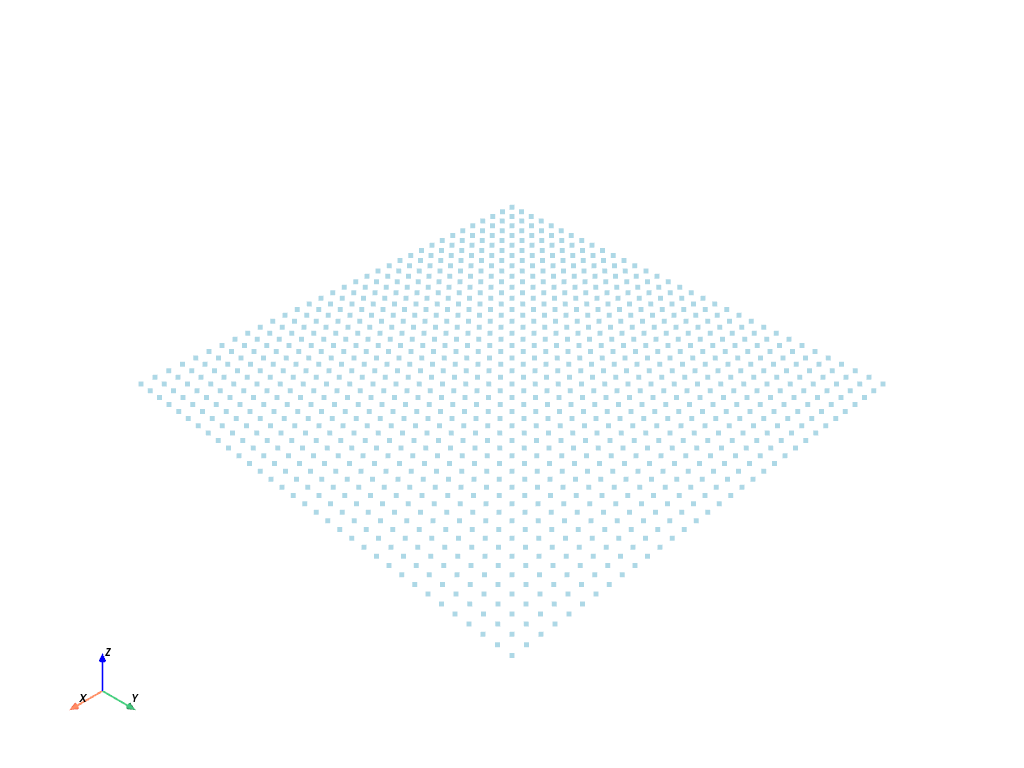

In [ ]:
# import pyvista as pv
# from dolfinx.plot import vtk_mesh

# # create a VTK mesh and attach the solution values from u_h as cell data
# out = vtk_mesh(u_h.function_space.mesh)
# pyvista_mesh = pv.wrap(out[-1])
# pyvista_mesh.plot()

In [32]:
u_h = w_h.sub(1).collapse()

MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


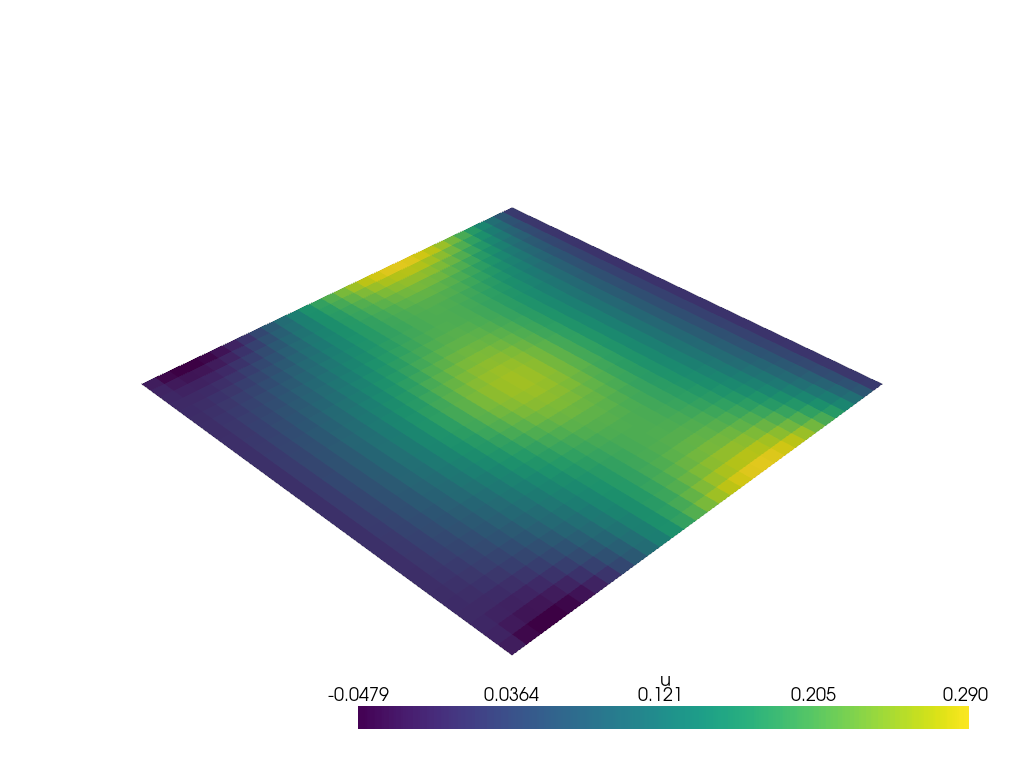

In [ ]:
# import pyvista
# from dolfinx import plot

# mesh = u_h.function_space.mesh
# cells, types, x = plot.vtk_mesh(mesh, mesh.topology.dim)
# grid = pyvista.UnstructuredGrid(cells, types, x)

# # If 2D vector field, reshape to (N, 2)
# grid["u"] = u_h.x.array
# # grid["u_y"] = vals[:, 1]
# # grid["u_mag"] = np.sqrt(vals[:, 0]**2 + vals[:, 1]**2)

# plotter = pyvista.Plotter()
# plotter.add_mesh(grid, scalars="u", cmap="viridis")
# plotter.show()

In [ ]:
# import numpy as np
# import dolfinx
# from dolfinx import mesh, fem, io
# from mpi4py import MPI
# import ufl
# import pyvista

# # Make sure PyVista is set to work inside Jupyter

# # 1. Create or import a 2D mesh
# # -------------------------------------------------------
# # For a simple rectangle, we can directly create a rectangular mesh. For the cylinder,
# # we can either embed it in the mesh with gmsh or approximate a circle with a refined region.
# # As a simplistic approach here, we'll just do a rectangle. To truly have a cylinder, 
# # you typically use gmsh or an external tool. We'll illustrate a rectangle for demonstration.

# L = 2.2
# H = 0.41
# nx, ny = 50, 10  # mesh resolution

# domain_mesh = mesh.create_rectangle(
#     MPI.COMM_WORLD,
#     [np.array([0.0, 0.0]), np.array([L, H])],
#     [nx, ny],
#     cell_type=mesh.CellType.triangle
# )

# # 2. Define function spaces for velocity (vector) and pressure (scalar)
# # -------------------------------------------------------
# V = fem.functionspace(domain_mesh, ("CG", 2))  # velocity space (quadratic)
# Q = fem.functionspace(domain_mesh, ("CG", 1))  # pressure space (linear)

# # 3. Mark boundaries and define boundary conditions
# # -------------------------------------------------------
# # Let's define boundary markers for:
# #  - Inflow (x=0)
# #  - Outflow (x=L)
# #  - Walls (y=0 or y=H)
# #  We'll assume no-slip on the walls for velocity,
# #  inflow has a parabolic velocity profile,
# #  outflow uses a "do-nothing" or zero normal gradient for velocity (implicitly).

# # A helper function to identify boundaries:
# def boundary_inflow(x):
#     return np.isclose(x[0], 0.0)

# def boundary_outflow(x):
#     return np.isclose(x[0], L)

# def boundary_walls(x):
#     return np.isclose(x[1], 0.0) | np.isclose(x[1], H)

# # Let's define a parabolic inflow profile u(y) = 4*U_max*y*(H - y)/H^2
# U_max = 1.0

# def inflow_velocity_expression(x):
#     # Parabolic in the vertical (y) direction
#     return np.stack((4 * U_max * x[1] * (H - x[1]) / H**2, 
#                      np.zeros_like(x[1]))).T

# # Now let's turn that into a Dirichlet BC
# #  We will create a fem.Function that we can use for boundary conditions.
# inflow_velocity = fem.Function(V)
# inflow_velocity.x.array[:] = 0.0

# # Interpolate the expression
# inflow_velocity.interpolate(inflow_velocity_expression)

# # For the no-slip boundary condition, the velocity is (0,0).
# noslip_velocity = np.array([0.0, 0.0], dtype=np.float64)

# # Create Dirichlet boundary conditions
# bc_inflow = fem.dirichletbc(inflow_velocity, fem.locate_dofs_geometrical(V, boundary_inflow))
# bc_walls = fem.dirichletbc(noslip_velocity, fem.locate_dofs_geometrical(V, boundary_walls), V)
# # We won't explicitly set Dirichlet for the outflow in velocity, so that
# # do-nothing condition is used for the outflow (typical for Navier–Stokes).

# bcs = [bc_inflow, bc_walls]

# # 4. Define Navier–Stokes problem (steady-state)
# # -------------------------------------------------------
# # We solve:
# #   rho*(u · grad(u)) - div(sigma(u,p)) = 0
# #   div(u) = 0
# # where sigma(u,p) = 2*mu*eps(u) - pI and eps(u) is the strain rate.
# # For simplicity, let's set density=1, viscosity=0.001

# mu = 1.0e-3
# u = fem.Function(V)
# v = ufl.TestFunction(V)
# p = fem.Function(Q)
# q = ufl.TestFunction(Q)

# u_trial = ufl.TrialFunction(V)
# p_trial = ufl.TrialFunction(Q)

# u_n = fem.Function(V)  # for iteration

# # Nonlinear form for Navier–Stokes
# # Strain-rate tensor
# def epsilon(u_):
#     return 0.5*(ufl.grad(u_) + ufl.grad(u_).T)

# F_momentum = (ufl.inner(u_n*ufl.grad(u_n), v)*ufl.dx
#               + 2*mu*ufl.inner(epsilon(u_n), epsilon(v))*ufl.dx
#               - ufl.div(v)*p*ufl.dx
#               )

# F_continuity = (ufl.div(u_n)*q*ufl.dx)

# F = F_momentum + F_continuity

# # We can use a Picard or Newton iteration. For demonstration, let's do Picard iteration.

# # 5. Assemble system & solve iteratively
# # -------------------------------------------------------
# # We'll do multiple iterations: on each iteration, we solve a linear sub-problem for u, p.

# solver_tolerance = 1e-6
# max_iterations = 20

# # Pre-create linear solvers for velocity and pressure
# u_solver = fem.LinearProblem(
#     ufl.lhs(F_momentum),
#     ufl.rhs(F_momentum),
#     bcs=bcs,
#     petsc_options={"ksp_type": "gmres", "pc_type": "ilu"}
# )

# p_solver = fem.LinearProblem(
#     ufl.lhs(F_continuity),
#     ufl.rhs(F_continuity),
#     bcs=[],  # Pressure typically no Dirichlet BC in standard formulation
#     petsc_options={"ksp_type": "gmres", "pc_type": "ilu"}
# )

# for i in range(max_iterations):
#     # Solve for velocity with the current pressure guess
#     u_solver.A = fem.assemble_matrix(ufl.lhs(F_momentum), bcs=bcs)
#     u_solver.b = fem.assemble_vector(ufl.rhs(F_momentum))
#     fem.apply_lifting(u_solver.b, [u_solver.A], [bcs])
#     u_solver.b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
#     u_solver.solve(u)
    
#     # Solve for pressure with updated velocity
#     p_solver.A = fem.assemble_matrix(ufl.lhs(F_continuity))
#     p_solver.b = fem.assemble_vector(ufl.rhs(F_continuity))
#     p_solver.solve(p)

#     # Compute update error
#     u_diff = fem.Function(V)
#     u_diff.vector.array[:] = u.vector.array - u_n.vector.array
#     error_u = np.linalg.norm(u_diff.vector.array, ord=np.inf)

#     # Copy the new solution into u_n for the next iteration
#     u_n.x.array[:] = u.x.array
    
#     if MPI.COMM_WORLD.rank == 0:
#         print(f"Iteration {i}, velocity update norm = {error_u:.6e}")

#     if error_u < solver_tolerance:
#         if MPI.COMM_WORLD.rank == 0:
#             print("Converged!")
#         break

# # 6. Visualize results inside the notebook
# # -------------------------------------------------------
# # We can use PyVista to visualize the solution fields.

# # Convert solution functions to a PyVista mesh
# topology, cell_types, geometry = dolfinx.plot.create_vtk_mesh(domain_mesh, domain_mesh.topology.dim)
# grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

# # Get velocity array
# u_vals = np.zeros((domain_mesh.topology.index_map(domain_mesh.topology.dim).size_local, 2))
# u_vals[:] = u.x.array.reshape((-1, 2))  # shape: (num_vertices, 2)
# grid["u_x"] = u_vals[:, 0]
# grid["u_y"] = u_vals[:, 1]

# # Get pressure array
# p_vals = p.x.array
# grid["p"] = p_vals

# # Plot velocity magnitude
# plotter = pyvista.PlotterITK()
# plotter.add_mesh(grid.copy(), scalars=np.sqrt(u_vals[:,0]**2 + u_vals[:,1]**2), 
#                  cmap="viridis", show_edges=False)
# plotter.add_title("Velocity Magnitude")
# plotter.show()

# # Similarly, we can plot pressure
# plotter_p = pyvista.PlotterITK()
# plotter_p.add_mesh(grid.copy(), scalars=p_vals, cmap="plasma", show_edges=False)
# plotter_p.add_title("Pressure")
# plotter_p.show()

# # 7. (Optional) Save solutions for offline processing
# # -------------------------------------------------------
# with io.XDMFFile(MPI.COMM_WORLD, "navier_stokes_solution.xdmf", "w") as xdmf:
#     xdmf.write_mesh(domain_mesh)
#     xdmf.write_function(u, "velocity")
#     xdmf.write_function(p, "pressure")


In [ ]:
# """
# This program solves steady‐state Darcy’s flow on a square plate
# with spatially varying permeability.
#       (K/mu)*u + grad(p) = 0
#                 div(u) = 0

# Weak form:
#    (v, (K/mu)*u) – (div(v), p) = 0    for all v
#             (q, div(u)) = 0          for all q
# """

# import numpy as np
# import math
# from mpi4py import MPI
# from petsc4py import PETSc

# from dolfinx import mesh, fem, io
# import ufl
# from basix.ufl import element
# # from ufl.finiteelement import MixedElement 

# # Create a unit square mesh (using dolfinx.mesh.create_rectangle).
# comm = MPI.COMM_WORLD
# # Here we choose 150 divisions in each direction and triangular cells.
# domain_mesh = mesh.create_rectangle(comm,
#                                     points=np.array([[0.0, 0.0],
#                                                      [1.0, 1.0]], dtype=np.float64),
#                                     n=(150, 150),
#                                     cell_type=mesh.CellType.triangle)

# # Define a scalar function space (for projecting permeability)
# V = fem.functionspace(domain_mesh, ("Lagrange", 1))

# # Create an XDMFFile for writing projected permeability values.
# with io.XDMFFile(comm, "results/porous_Ks.xdmf", "w") as xdmf_k:
# # xdmf_k = io.XDMFFile(comm, "results/porous_Ks.xdmf", "w")
#     xdmf_k.write_mesh(domain_mesh)

#     pi = math.pi
#     N_param = 15
#     A_vals = np.linspace(0.0, 1.0, N_param)
#     B_vals = np.linspace(0.0, 4.0, N_param)

#     # Create a Function for the permeability coefficient in V.
#     k_func = fem.Function(V)
#     # Get the dof coordinates (reshaped to (num_dofs, 2)).
#     dof_coords = V.tabulate_dof_coordinates()

#     # Loop over parameters and “project” the permeability coefficient.
#     n = 0
#     for i in range(N_param):
#         for j in range(N_param):
#             A = A_vals[i]
#             B = B_vals[j]
#             # Define k(x) = exp(-4*A*x₀)*|sin(2πx₀)|*|cos(2πB*x₁)| + 1.0
#             values = np.exp(-4 * A * dof_coords[:, 0]) * \
#                     np.abs(np.sin(2 * pi * dof_coords[:, 0])) * \
#                     np.abs(np.cos(2 * pi * B * dof_coords[:, 1])) + 1.0
#             k_func.x.array[:] = values
#             k_func.x.scatter_forward()
#             n += 1
#             if n % 20 == 0 and comm.rank == 0:
#                 print("n =", n)
#             xdmf_k.write_function(k_func, n)

# # Define viscosity.
# mu = 10.0

# # -------------------------------------------------------------------------
# # Now set up the mixed (velocity-pressure) problem.
# # We want to solve for u (vector) and p (scalar) on the same mesh.

# element_u = element("Lagrange", domain_mesh.cell_name(), 2, shape=(domain_mesh.geometry.dim, ))
# element_p = element("Lagrange", domain_mesh.ufl_cell(), 1)
# # W_elem = ufl.MixedElement([element_u, element_p])
# W = fem.functionspace(domain_mesh, element_u * element_p)

# # Define trial and test functions.
# u = TrialFunction(V)
# v = TestFunction(V)
# p = TrialFunction(Q)
# q = TestFunction(Q)

# # Define a tolerance for boundary location.
# tol = 1e-8

# # Boundary marker functions.
# def inflow(x):
#     return np.isclose(x[0], 0.0, atol=tol)

# def outflow(x):
#     return np.isclose(x[0], 1.0, atol=tol)

# def walls(x):
#     return np.logical_or(np.isclose(x[1], 0.0, atol=tol),
#                          np.isclose(x[1], 1.0, atol=tol))

# # Create Dirichlet boundary conditions.
# # For pressure: p = 1.0 at inflow and p = 0.0 at outflow.
# dofs_inflow = fem.locate_dofs_geometrical(W.sub(1), inflow)
# bc_inflow = fem.dirichletbc(PETSc.ScalarType(1.0), dofs_inflow, W.sub(1))

# dofs_outflow = fem.locate_dofs_geometrical(W.sub(1), outflow)
# bc_outflow = fem.dirichletbc(PETSc.ScalarType(0.0), dofs_outflow, W.sub(1))

# # For velocity, we want to enforce free‐slip on the walls, i.e. only the y‐component is set to zero.
# # First, locate all dofs for the velocity (subspace 0) on the wall boundaries.
# dofs_walls_all = fem.locate_dofs_geometrical(W.sub(0), walls)
# # --- Assuming an interleaved ordering of the 2D vector dofs,
# # the y‑component is stored in every second entry (i.e. indices 1, 3, 5, ...).
# dofs_walls_y = dofs_walls_all[dofs_walls_all % 2 == 1]
# bc_walls = fem.dirichletbc(PETSc.ScalarType(0.0), dofs_walls_y, W.sub(0))

# # Gather all boundary conditions.
# bcs = [bc_walls, bc_inflow, bc_outflow]

# # -------------------------------------------------------------------------
# # Define the variational forms.
# dx = ufl.dx

# # The bilinear form is:
# #   a((u,p); (v,q)) = ((mu/k)*v, u)_L2 + (grad(p), v)_L2 + (div(u), q)_L2.
# # (Here we use the permeability function k_func which we will update in the loop.)
# a = fem.form(ufl.dot((mu / k_func) * v, u) * dx +
#              ufl.inner(ufl.grad(p), v) * dx +
#              q * ufl.div(u) * dx)
# # Right-hand side is zero.
# L = fem.form(q * 0 * dx)

# # Create XDMF files for writing the velocity and pressure solutions.
# xdmf_u = io.XDMFFile(comm, "results/velocity_Kall.xdmf", "w")
# xdmf_u.write_mesh(domain_mesh)
# xdmf_p = io.XDMFFile(comm, "results/pressure_Kall.xdmf", "w")
# xdmf_p.write_mesh(domain_mesh)

# # Loop over parameter values, update the permeability coefficient, reassemble, and solve.
# n = 0
# for i in range(N_param):
#     for j in range(N_param):
#         Av = A_vals[i]
#         Bv = B_vals[j]
#         # Update k_func on V with the new parameters.
#         values = np.exp(-4 * Av * dof_coords[:, 0]) * \
#                  np.abs(np.sin(2 * pi * dof_coords[:, 0])) * \
#                  np.abs(np.cos(2 * pi * Bv * dof_coords[:, 1])) + 1.0
#         k_func.x.array[:] = values
#         k_func.x.scatter_forward()

#         n += 1
#         if n % 1 == 0 and comm.rank == 0:
#             print("Solving weak form n =", n, flush=True)
#         # Reassemble the variational forms with the updated k_func.
#         a = fem.form(ufl.dot((mu / k_func) * v, u) * dx +
#                      ufl.inner(ufl.grad(p), v) * dx +
#                      q * ufl.div(u) * dx)
#         L = fem.form(q * 0 * dx)
#         # Set up and solve the linear problem.
#         # (Here we use PETSc’s LU solver.)
#         problem = fem.petsc.LinearProblem(a, L, bcs=bcs,
#                                           petsc_options={"ksp_type": "preonly",
#                                                          "pc_type": "lu"})
#         w_sol = problem.solve()
#         # Split the mixed solution into velocity and pressure parts.
#         u_sol, p_sol = w_sol.split()
#         u_sol.name = "u_sol"
#         p_sol.name = "p_sol"
#         xdmf_u.write_function(u_sol, n)
#         xdmf_p.write_function(p_sol, n)
#         if comm.rank == 0:
#             print("Written", flush=True)


n = 20
n = 40
n = 60
n = 80
n = 100
n = 120
n = 140
n = 160
n = 180
n = 200
n = 220


AttributeError: 'Mesh' object has no attribute 'cell_name'